# SARIMA

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller




In [3]:
DATA_PATH = Path("../data/processed/ptf_processed.parquet")

df =pd.read_parquet(DATA_PATH)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"],errors="coerce")
    df = df.dropna(subset=["date"])
    df =df.set_index("date")

df = df.sort_index()
df["ptf"] = pd.to_numeric(df["ptf"],errors="coerce")
df = df.dropna(subset=["ptf"])

print(df.shape)
df.head()



(71664, 8)


,hour,ptf,priceUsd,priceEur,_chunk_start,_chunk_end,year,month
date,,,,,,,,
2018-01-01 00:00:00+03:00,00:00,207.60,55.04,45.97,2018-01-01,2018-01-30,2018,1
2018-01-01 01:00:00+03:00,01:00,205.34,54.44,45.47,2018-01-01,2018-01-30,2018,1
2018-01-01 02:00:00+03:00,02:00,164.94,43.73,36.53,2018-01-01,2018-01-30,2018,1
2018-01-01 03:00:00+03:00,03:00,154.52,40.97,34.22,2018-01-01,2018-01-30,2018,1
2018-01-01 04:00:00+03:00,04:00,112.64,29.86,24.95,2018-01-01,2018-01-30,2018,1


In [4]:
series =df["ptf"].copy()

print("Start:",series.index.min())
print("End:",series.index.max())
print("Shape:",series.shape)



Start: 2018-01-01 00:00:00+03:00
End: 2026-03-05 23:00:00+03:00
Shape: (71664,)


In [5]:
series = series.iloc[-24 * 365 * 2:].copy()

print("Filtered Shape",series.shape)
print("Start:", series.index.min())
print("End  :", series.index.max())

Filtered Shape (17520,)
Start: 2024-03-06 00:00:00+03:00
End  : 2026-03-05 23:00:00+03:00


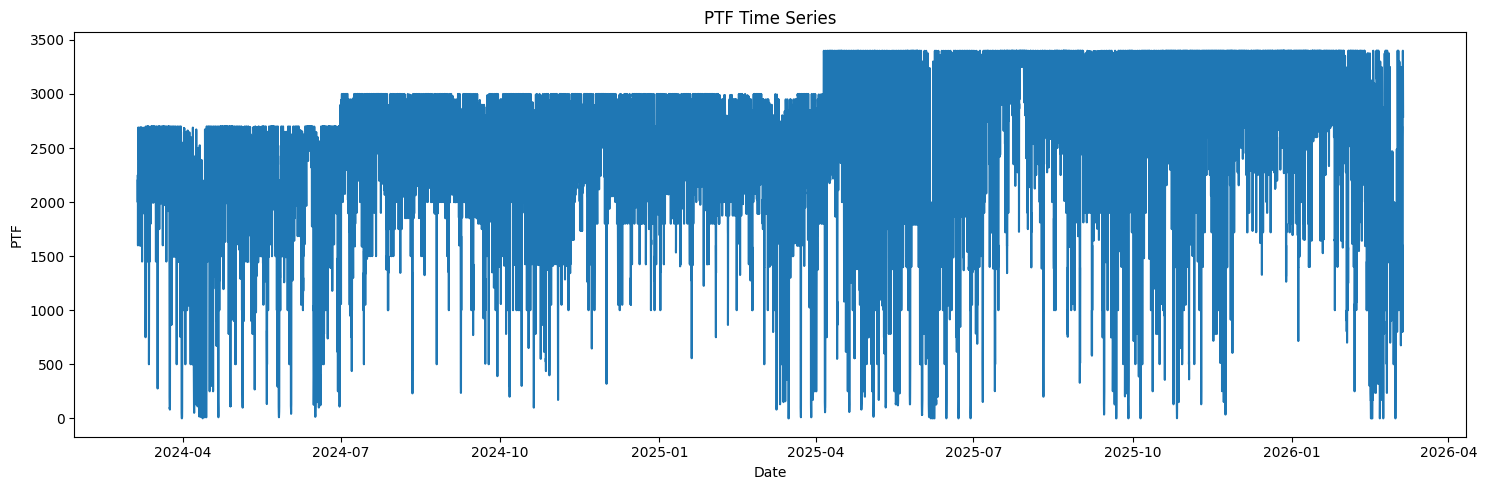

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(series.index, series.values)
plt.title("PTF Time Series")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.tight_layout()
plt.show()

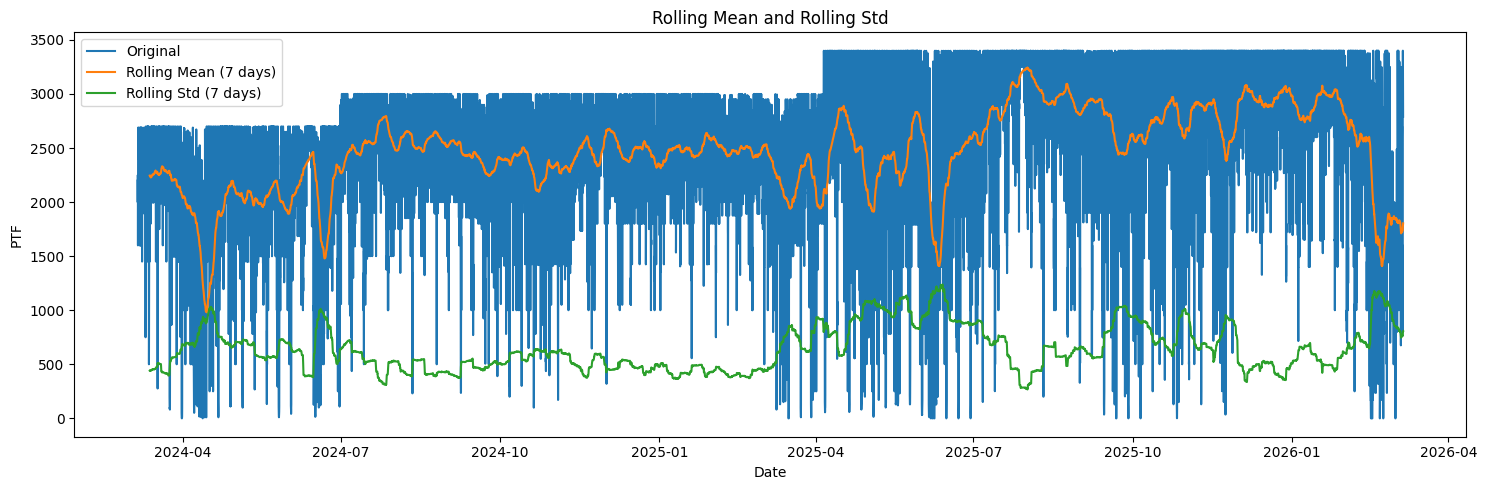

In [7]:
rolling_mean = series.rolling(window=24 * 7).mean()
rolling_std = series.rolling(window=24 * 7).std()

plt.figure(figsize=(15, 5))
plt.plot(series.index, series.values, label="Original")
plt.plot(rolling_mean.index, rolling_mean.values, label="Rolling Mean (7 days)")
plt.plot(rolling_std.index, rolling_std.values, label="Rolling Std (7 days)")
plt.title("Rolling Mean and Rolling Std")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
def adf_test(series, name="Series"):
    series = series.dropna()

    result = adfuller(series)

    print(f"ADF Test - {name}")
    print("-" * 40)
    print(f"Test Statistic : {result[0]:.6f}")
    print(f"p-value        : {result[1]:.6f}")
    print(f"Lags Used      : {result[2]}")
    print(f"N Observations : {result[3]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.6f}")

    if result[1] < 0.05:
        print("\nResult: Series is likely STATIONARY.")
    else:
        print("\nResult: Series is likely NON-STATIONARY.")

In [9]:
adf_test(series, name="Original PTF Series")

ADF Test - Original PTF Series
----------------------------------------
Test Statistic : -9.957062
p-value        : 0.000000
Lags Used      : 44
N Observations : 17475
Critical Values:
   1%: -3.430724
   5%: -2.861705
   10%: -2.566858

Result: Series is likely STATIONARY.


In [10]:
series_diff_1 = series.diff(1)

adf_test(series_diff_1, name="1st Difference")

ADF Test - 1st Difference
----------------------------------------
Test Statistic : -29.975817
p-value        : 0.000000
Lags Used      : 44
N Observations : 17474
Critical Values:
   1%: -3.430724
   5%: -2.861705
   10%: -2.566858

Result: Series is likely STATIONARY.


In [11]:
series_seasonal_diff = series.diff(24)

adf_test(series_seasonal_diff, name="Seasonal Difference (24)")

ADF Test - Seasonal Difference (24)
----------------------------------------
Test Statistic : -24.493768
p-value        : 0.000000
Lags Used      : 44
N Observations : 17451
Critical Values:
   1%: -3.430725
   5%: -2.861706
   10%: -2.566858

Result: Series is likely STATIONARY.


In [12]:
series_diff_both = series.diff(1).diff(24)

adf_test(series_diff_both, name="1st + Seasonal Difference (24)")

ADF Test - 1st + Seasonal Difference (24)
----------------------------------------
Test Statistic : -28.468985
p-value        : 0.000000
Lags Used      : 44
N Observations : 17450
Critical Values:
   1%: -3.430725
   5%: -2.861706
   10%: -2.566858

Result: Series is likely STATIONARY.


<Figure size 1500x500 with 0 Axes>

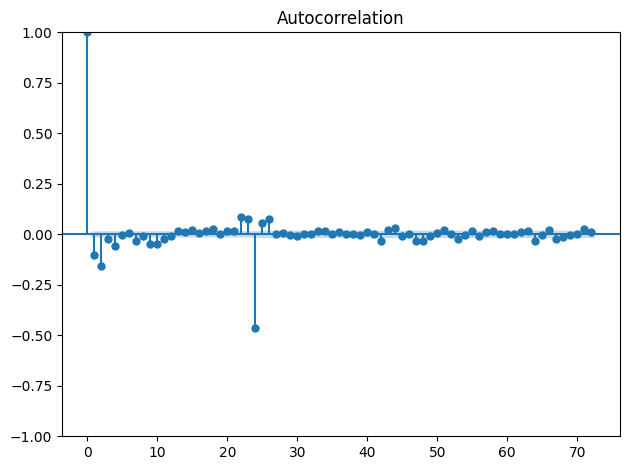

In [13]:
analysis_series = series.diff(1).diff(24).dropna()

plt.figure(figsize=(15, 5))
plot_acf(analysis_series, lags=72)
plt.tight_layout()
plt.show()

<Figure size 1500x500 with 0 Axes>

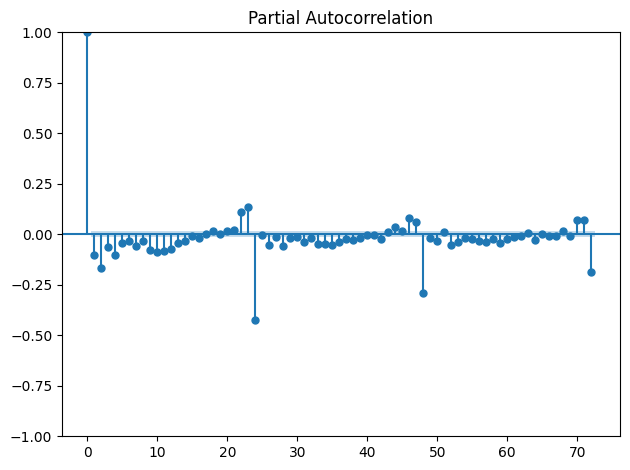

In [14]:
plt.figure(figsize=(15, 5))
plot_pacf(analysis_series, lags=72, method="ywm")
plt.tight_layout()
plt.show()

In [15]:
split_idx = int(len(series) * 0.8)

train = series.iloc[:split_idx].copy()
test = series.iloc[split_idx:].copy()

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Train start:", train.index.min(), "| Train end:", train.index.max())
print("Test start :", test.index.min(), "| Test end :", test.index.max())

Train shape: (14016,)
Test shape : (3504,)
Train start: 2024-03-06 00:00:00+03:00 | Train end: 2025-10-10 23:00:00+03:00
Test start : 2025-10-11 00:00:00+03:00 | Test end : 2026-03-05 23:00:00+03:00


In [16]:
def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
    }

In [20]:
baseline_pred = series.shift(24).iloc[split_idx:]

valid_mask = test.notna() & baseline_pred.notna()

baseline_metrics = evaluate_forecast(
    y_true=test[valid_mask],
    y_pred=baseline_pred[valid_mask]
)

baseline_metrics

{'MAE': 457.1082619863014,
 'RMSE': np.float64(723.3324309578348),
 'MAPE': np.float64(136.8856214891718)}

In [21]:
order = (1,0,1)
seasonal_order = (1,1,1,24)


In [23]:
model = SARIMAX(
    train,
    order =order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
print(result.summary())

c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                ptf   No. Observations:                14016
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -99144.432
Date:                            Tue, 10 Mar 2026   AIC                         198298.863
Time:                                    16:10:26   BIC                         198336.585
Sample:                                03-06-2024   HQIC                        198311.423
                                     - 10-10-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8334      0.004    200.124      0.000       0.825       0.842
ma.L1          0.0269      0.007   

In [24]:
forecast = result.forecast(steps=len(test))
forecast =pd.Series(forecast,index=test.index,name="sarima_pred")

sarima_metrics = evaluate_forecast(test,forecast)
sarima_metrics

{'MAE': 568.5731005204855,
 'RMSE': np.float64(798.2536901521668),
 'MAPE': np.float64(154.22466287083137)}

In [25]:
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline_lag24",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "MAPE": baseline_metrics["MAPE"],
    },
    {
        "Model": "SARIMA(1,1,1)(1,1,1,24)",
        "MAE": sarima_metrics["MAE"],
        "RMSE": sarima_metrics["RMSE"],
        "MAPE": sarima_metrics["MAPE"],
    }
])

comparison_df

,Model,MAE,RMSE,MAPE
0,Baseline_lag24,457.108262,723.332431,136.885621
1,"SARIMA(1,1,1)(1,1,1,24)",568.573101,798.253690,154.224663


In [26]:
def sarima_grid_search(train, test, pdq_list, seasonal_pdq_list, seasonal_period=24):
    results = []

    for order in pdq_list:
        for seasonal in seasonal_pdq_list:
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], seasonal_period)

            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fitted = model.fit(disp=False)
                forecast = fitted.forecast(steps=len(test))

                metrics = evaluate_forecast(test, forecast)

                results.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": fitted.aic,
                    "MAE": metrics["MAE"],
                    "RMSE": metrics["RMSE"],
                    "MAPE": metrics["MAPE"],
                })

                print(f"Done: order={order}, seasonal_order={seasonal_order}, MAE={metrics['MAE']:.2f}")

            except Exception as e:
                print(f"Failed: order={order}, seasonal_order={seasonal_order} | {e}")
                continue

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("MAE").reset_index(drop=True)

    return results_df

In [28]:
from itertools import product
p = [0, 1, 2]
d = [1]
q = [0, 1, 2]

P = [0, 1]
D = [1]
Q = [0, 1]

pdq_list = list(product(p, d, q))
seasonal_pdq_list = list(product(P, D, Q))

print("Number of non-seasonal combos:", len(pdq_list))
print("Number of seasonal combos    :", len(seasonal_pdq_list))
print("Total models to try          :", len(pdq_list) * len(seasonal_pdq_list))

Number of non-seasonal combos: 9
Number of seasonal combos    : 4
Total models to try          : 36


In [29]:
sarima_result = sarima_grid_search(
    train=train,
    test = test,
    pdq_list=pdq_list,
    seasonal_pdq_list = seasonal_pdq_list,
    seasonal_period=24
)

c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done: order=(0, 1, 0), seasonal_order=(0, 1, 0, 24), MAE=9374.95


c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done: order=(0, 1, 0), seasonal_order=(0, 1, 1, 24), MAE=1344.57


c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


...

Done: order=(2, 1, 2), seasonal_order=(0, 1, 1, 24), MAE=1724.24


c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Done: order=(2, 1, 2), seasonal_order=(1, 1, 0, 24), MAE=558.27


c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done: order=(2, 1, 2), seasonal_order=(1, 1, 1, 24), MAE=1523.21


In [30]:
sarima_result.head(10)

,order,seasonal_order,AIC,MAE,RMSE,MAPE
0,"(2, 1, 2)","(1, 1, 0, 24)",203124.658309,558.269540,863.371673,200.747716
1,"(1, 1, 2)","(1, 1, 0, 24)",203200.327542,558.393945,863.403421,200.705962
2,"(1, 1, 1)","(1, 1, 0, 24)",203299.238334,559.925955,865.015824,200.912407
3,"(2, 1, 1)","(1, 1, 0, 24)",203225.239573,559.982649,865.090866,200.890344
4,"(2, 1, 2)","(0, 1, 0, 24)",206167.940352,571.343813,879.091243,181.712661
5,"(1, 1, 2)","(0, 1, 0, 24)",206223.015538,572.901020,880.563687,181.878335
6,"(1, 1, 1)","(0, 1, 0, 24)",206214.855618,572.931442,880.590134,181.893080
7,"(2, 1, 1)","(0, 1, 0, 24)",206245.718041,573.085744,880.751064,181.901925
8,"(1, 1, 1)","(1, 1, 1, 24)",198284.027575,1117.877363,1453.326904,228.088432
9,"(0, 1, 2)","(1, 1, 1, 24)",198908.309871,1123.440293,1461.115900,228.134434


In [31]:
best_row = sarima_result.iloc[0]

best_order = best_row["order"]
best_seasonal_order = best_row["seasonal_order"]

print("Best order :",best_order)
print("Best seasonal order:",best_seasonal_order)
print("Best MAE :",best_row["MAE"])

Best order : (2, 1, 2)
Best seasonal order: (1, 1, 0, 24)
Best MAE : 558.269540110884


In [32]:
best_model = SARIMAX(
    train,
    order = best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_result = best_model.fit(dist=False)
best_forecast = best_result.forecast(steps=len(test))
best_forecast =pd.Series(best_forecast,index=test.index,name="best_sarima_pred")

best_metrics = evaluate_forecast(test,best_forecast)
best_metrics


c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\berke\Desktop\teias-price-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


{'MAE': 558.269540110884,
 'RMSE': np.float64(863.3716731633488),
 'MAPE': np.float64(200.74771560245503)}

In [33]:
final_comparison = pd.DataFrame([
    {
        "Model": "Baseline_lag24",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "MAPE": baseline_metrics["MAPE"],
    },
    {
        "Model": f"SARIMA{best_order}{best_seasonal_order}",
        "MAE": best_metrics["MAE"],
        "RMSE": best_metrics["RMSE"],
        "MAPE": best_metrics["MAPE"],
    }
])

final_comparison

,Model,MAE,RMSE,MAPE
0,Baseline_lag24,457.108262,723.332431,136.885621
1,"SARIMA(2, 1, 2)(1, 1, 0, 24)",558.269540,863.371673,200.747716


In [41]:
plot_df = pd.DataFrame({
    "actual" :test,
    "baseline_lag24" : baseline_pred,
    "sarima_pred" : best_forecast,
}).dropna()

plot_df = plot_df.iloc[:24*24]
plot_df.head()

,actual,baseline_lag24,sarima_pred
date,,,
2025-10-11 00:00:00+03:00,3097.01,3219.47,3247.595815
2025-10-11 01:00:00+03:00,3150.00,3000.00,3075.851033
2025-10-11 02:00:00+03:00,2913.64,2510.00,2675.249154
2025-10-11 03:00:00+03:00,2749.99,2500.00,2522.492692
2025-10-11 04:00:00+03:00,2667.02,2792.00,2842.341855


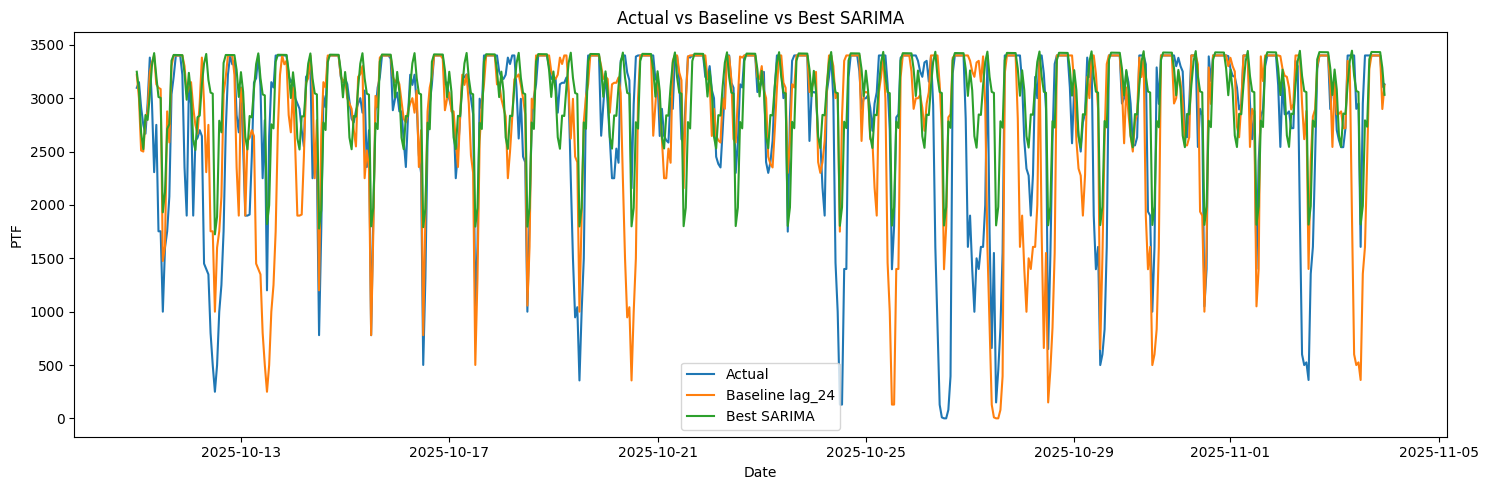

In [42]:
plt.figure(figsize=(15, 5))
plt.plot(plot_df.index, plot_df["actual"], label="Actual")
plt.plot(plot_df.index, plot_df["baseline_lag24"], label="Baseline lag_24")
plt.plot(plot_df.index, plot_df["sarima_pred"], label="Best SARIMA")
plt.title("Actual vs Baseline vs Best SARIMA")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.legend()
plt.tight_layout()
plt.show()

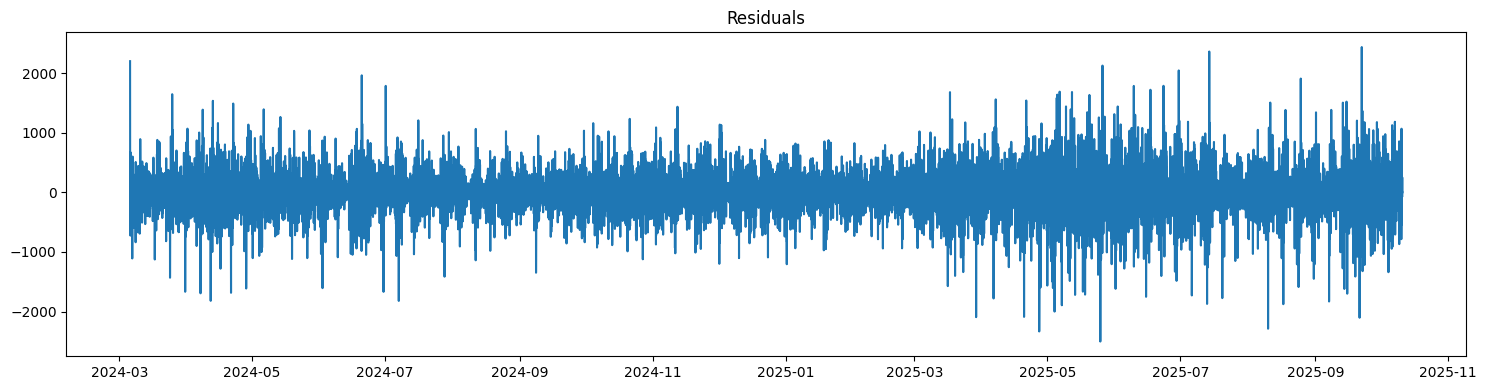

In [43]:
residuals = best_result.resid

plt.figure(figsize=(15, 4))
plt.plot(residuals)
plt.title("Residuals")
plt.tight_layout()
plt.show()

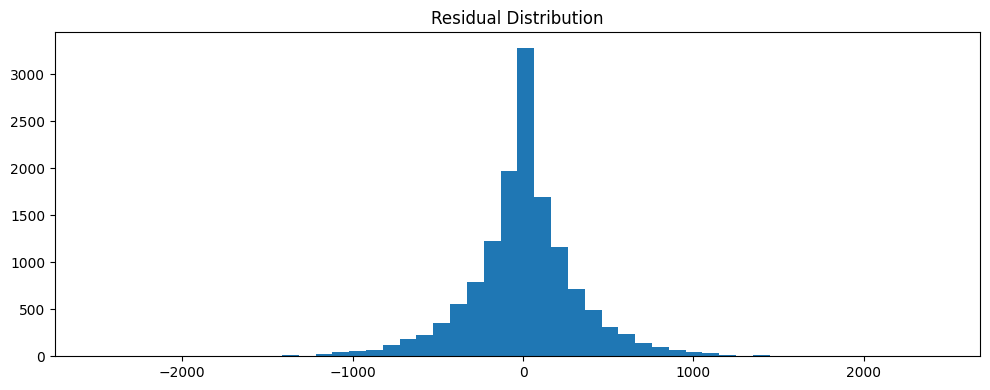

In [45]:
plt.figure(figsize=(10, 4))
plt.hist(residuals.dropna(), bins=50)
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook, a SARIMA analysis was performed on the PTF time series.

The following steps were carried out:

- Stationarity analysis using the Augmented Dickey-Fuller (ADF) test
- Investigation of the need for differencing
- Autocorrelation and partial autocorrelation analysis (ACF / PACF)
- SARIMA hyperparameter search
- Comparison with a baseline lag-24 model

In the next step, the same dataset will be modeled using **LightGBM**, and the results of a classical time series approach will be compared with a machine learning approach.